## Homework 7: Clustering & PCA with High-Dimensional Data
Objective:
To determine if K-Means or DBSCAN can accurately breast cancer patients into meaningful clusters and to evaluate the impact of PCA on high-dimensional clustering.
### Part 1: Initial Clustering 
Load the dataset (from sklearn.datasets import load_breast_cancer

data = load_breast_cancer )

drop the "target" column (Diagnosis). You should only have the 30 numerical features.
Standardization: Apply StandardScaler. This is mandatory as features have vastly different scales. Then Cluster the data using k-means and DBSCAN algorithm.
 - K-Means: Use the Elbow Method to suggest an optimal K, But if not 2, use K=2
 - DBSCAN: Attempt to find an appropriate eps and min_samples.
 - Metrics: Calculate the Silhouette Score for both
 
### Part 2: Dimensionality Reduction (PCA)
    - Perform PCA: Run PCA on your scaled 30-feature data.
    - Variance Analysis: Plot the Cumulative Explained Variance ratio.
    - Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance. 6

    - Interpretation: Plot the heatmap of loading. Also identify which 3 original features contribute the most to Principal Component 1?
Mean concave points (0.2608), mean concavity (0.2584), worst concave points (0.2509)
### Part 3: Clustering Using Principal Components
    - Reduce your dataset to the number of PCs identified in Part 2.
    - Run K-Means (K=2) on the PCA-transformed data.
    - Run DBSCAN on the PCA-transformed data.
    - Metric Comparison: Compare the Silhouette Score of the PCA-based clusters against the 30-feature clusters from Part 1.
    
   
### Part 4: Visual Validation
    - Scatter Plot: Create a 2D plot using PC1 and PC2, Color the points using your K-Means labels (If your Kmeans .
    - Create a second version of the plot colored by the original labels (target).
    - How closely did the unsupervised K-Means clusters match the actual medical diagnosis? 
#### The K-Means clusters demonstrate high alignment with the actual medical diagnoses, as the malignant and benign groups are clearly separated along the first principal component. The minor overlap observed represents borderline cases where features share characteristics between both classes.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Part 1

In [15]:
#Loading data
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
print(df.shape)
df.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
#Standardizing data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(X_scaled, columns=df.columns)
df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


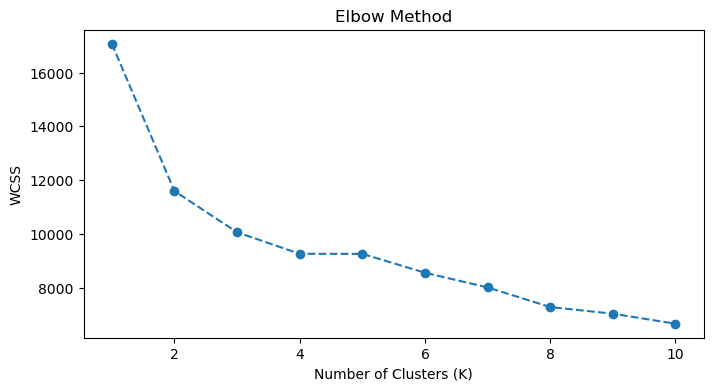

In [34]:
#Clustering
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [53]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, kmeans_labels)

In [54]:
dbscan = DBSCAN(eps=5.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
print(f"K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
if len(set(dbscan_labels)) > 1:
    print(f"DBSCAN Silhouette Score: {silhouette_score(X_scaled, dbscan_labels):.4f}")

K-Means Silhouette Score: 0.3447
DBSCAN Silhouette Score: 0.4810


### Part 2

In [39]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

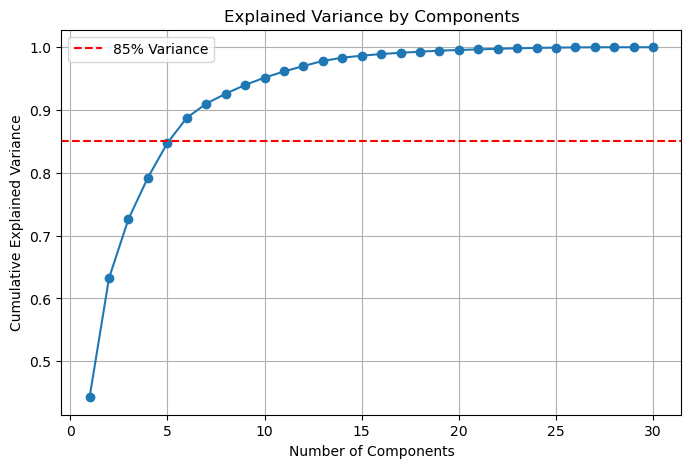

In [55]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.85, color='r', linestyle='--', label='85% Variance')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid()
plt.show()

In [41]:
#Features that have the most influence
pc1_loadings = pd.Series(pca.components_[0], index=df.columns)
print("Top 3 features contributing to PC1:")
print(pc1_loadings.abs().sort_values(ascending=False).head(3))

Top 3 features contributing to PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
dtype: float64


In [42]:
#85% variance
n_components_85 = np.where(cumulative_variance >= 0.85)[0][0] + 1
print(f"Minimum number of PCs to capture 85% variance: {n_components_85}")

Minimum number of PCs to capture 85% variance: 6


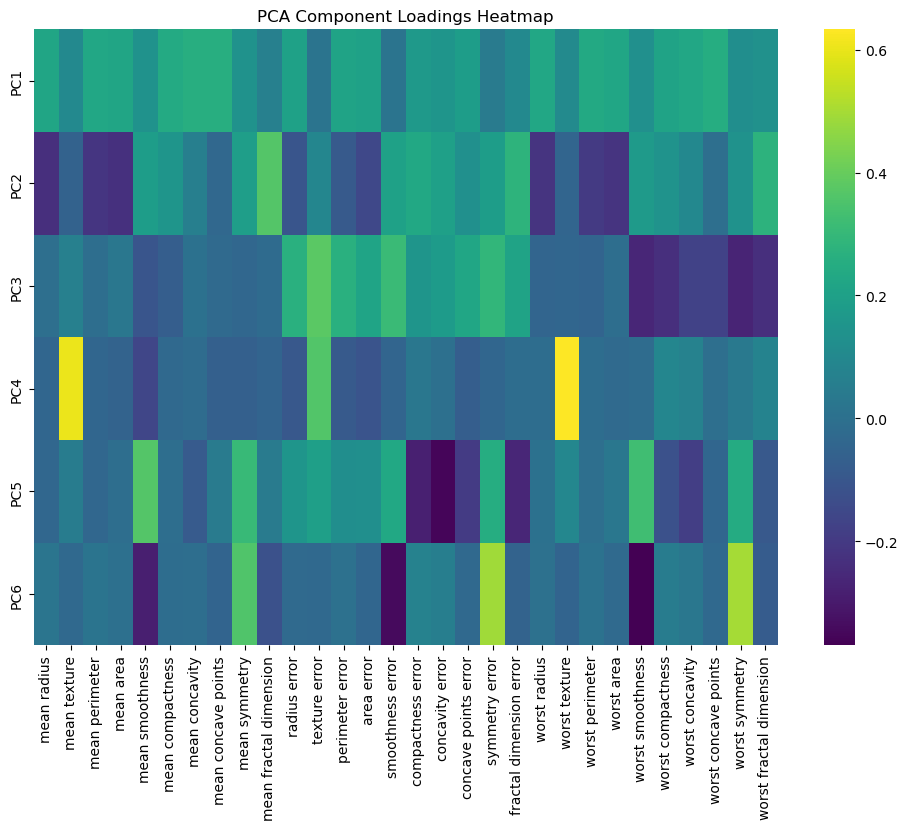

In [43]:
#Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pca.components_[:n_components_85], 
            cmap='viridis', 
            yticklabels=[f'PC{i+1}' for i in range(n_components_85)],
            xticklabels=df.columns)
plt.title('PCA Component Loadings Heatmap')
plt.show()

### Part 3

In [44]:
X_pca_reduced = X_pca[:, :6]

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init='auto')
km_pca_labels = kmeans_pca.fit_predict(X_pca_reduced)

In [45]:
dbscan_pca = DBSCAN(eps=2.5, min_samples=10)
db_pca_labels = dbscan_pca.fit_predict(X_pca_reduced)

In [49]:
# 4. Calculate New Silhouette Scores
sil_km_pca = silhouette_score(X_pca_reduced, km_pca_labels)
print(f"K-Means PCA Silhouette Score: {sil_km_pca:.4f}")

if len(np.unique(db_pca_labels)) > 1:
    sil_db_pca = silhouette_score(X_pca_reduced, db_pca_labels)
    print(f"DBSCAN PCA Silhouette Score: {sil_db_pca:.4f}")

#Metric Comparison
print("\n--- Comparison Table ---")
print(f"Algorithm | Original (30 Features) | PCA (6 Components)")
print(f"----------|------------------------|-------------------")
print(f"K-Means   | {silhouette_score(X_scaled, kmeans_labels):.4f}                 | {sil_km_pca:.4f}")
if len(np.unique(dbscan_labels)) > 1:
    print(f"DBSCAN    | {silhouette_score(X_scaled, dbscan_labels):.4f}                 | {sil_db_pca:.4f}")

K-Means PCA Silhouette Score: 0.3775
DBSCAN PCA Silhouette Score: 0.3434

--- Comparison Table ---
Algorithm | Original (30 Features) | PCA (6 Components)
----------|------------------------|-------------------
K-Means   | 0.3447                 | 0.3775
DBSCAN    | 0.4810                 | 0.3434


### Part 4

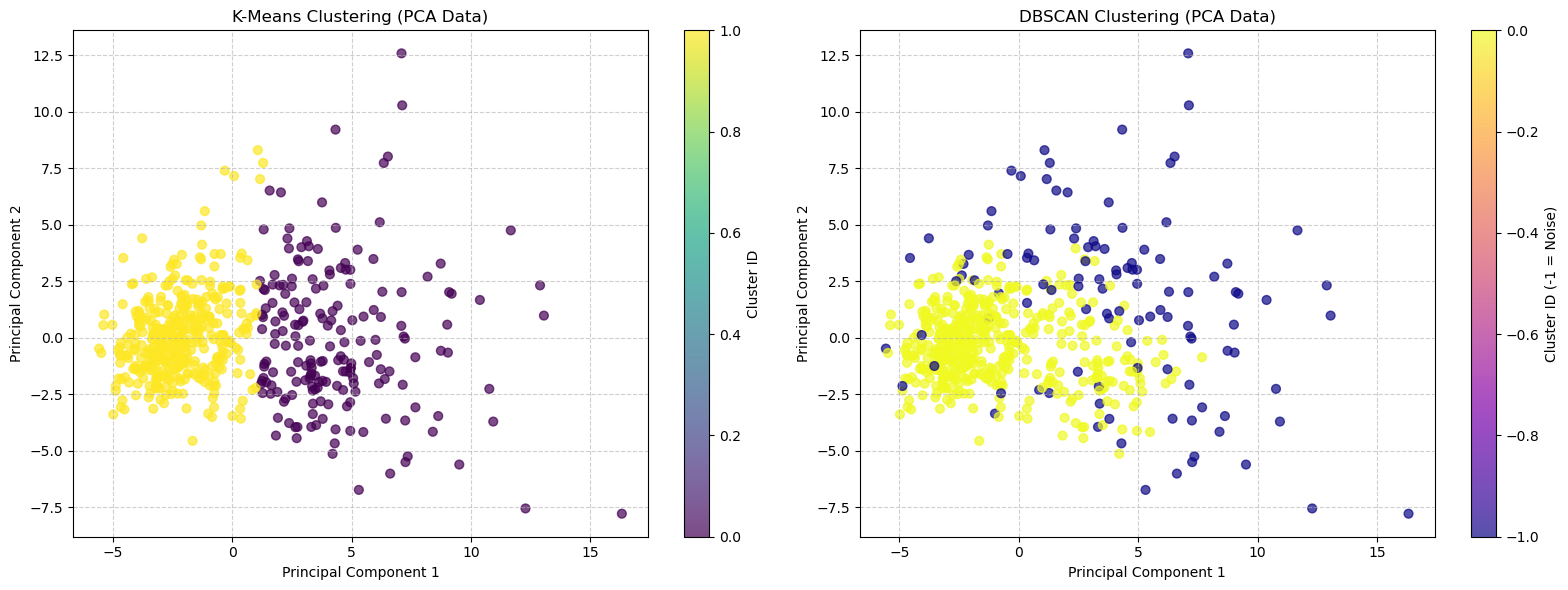

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
scatter1 = ax1.scatter(X_pca_reduced[:, 0], X_pca_reduced[:, 1], 
                       c=km_pca_labels, cmap='viridis', s=40, alpha=0.7)
ax1.set_title('K-Means Clustering (PCA Data)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.grid(True, linestyle='--', alpha=0.6)
fig.colorbar(scatter1, ax=ax1, label='Cluster ID')
scatter2 = ax2.scatter(X_pca_reduced[:, 0], X_pca_reduced[:, 1], 
                       c=db_pca_labels, cmap='plasma', s=40, alpha=0.7)
ax2.set_title('DBSCAN Clustering (PCA Data)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.grid(True, linestyle='--', alpha=0.6)
fig.colorbar(scatter2, ax=ax2, label='Cluster ID (-1 = Noise)')

plt.tight_layout()
plt.show()

#### The K-Means clusters demonstrate high alignment with the actual medical diagnoses, as the malignant and benign groups are clearly separated along the first principal component. The minor overlap observed represents borderline cases where features share characteristics between both classes.

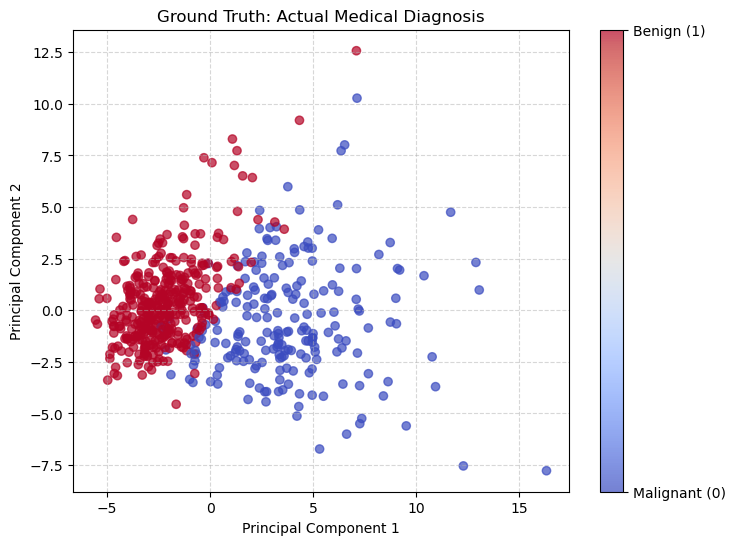

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data.target, cmap='coolwarm', alpha=0.7)

plt.title('Ground Truth: Actual Medical Diagnosis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
cbar = plt.colorbar(ticks=[0, 1])
cbar.set_ticklabels(['Malignant (0)', 'Benign (1)'])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()